In [6]:
data=pd.read_csv(r"/imbalanced_data.csv")
data.head()

,id,label,tweet
0,1,0,@user when a father is dysfunctional and is s...
1,2,0,@user @user thanks for #lyft credit i can't us...
2,3,0,bihday your majesty
3,4,0,#model i love u take with u all the time in ...
4,5,0,factsguide: society now #motivation


In [2]:
import pandas as pd
import numpy as np

In [7]:
import re

def clean_text(text):
    text = text.lower()

    text = re.sub(r'@\w+', '', text)
    text = re.sub(r'http\S+|www\S+', '', text)
    text = re.sub(r'[^a-z\s]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()

    return text

In [8]:
data['clean_tweet'] = data['tweet'].apply(clean_text)

In [9]:
data[['tweet', 'clean_tweet']].head()

,tweet,clean_tweet
0,@user when a father is dysfunctional and is s...,when a father is dysfunctional and is so selfi...
1,@user @user thanks for #lyft credit i can't us...,thanks for lyft credit i cant use cause they d...
2,bihday your majesty,bihday your majesty
3,#model i love u take with u all the time in ...,model i love u take with u all the time in ur
4,factsguide: society now #motivation,factsguide society now motivation


In [10]:
data = data[data['clean_tweet'] != '']

In [11]:
X = data['clean_tweet']
y = data['label']

In [12]:
data['tokens'] = data['clean_tweet'].apply(lambda x: x.split())

In [13]:
from collections import Counter

all_words = []

for tokens in data['tokens']:
    all_words.extend(tokens)

word_counts = Counter(all_words)

In [14]:
vocab_size = 5000
most_common_words = word_counts.most_common(vocab_size)

In [15]:
word_to_index = {'<PAD>': 0, '<OOV>': 1}

for i, (word, _) in enumerate(most_common_words, start=2):
    word_to_index[word] = i

In [16]:
def tokens_to_sequence(tokens):
    return [word_to_index.get(word, word_to_index['<OOV>']) for word in tokens]

data['sequence'] = data['tokens'].apply(tokens_to_sequence)

In [17]:
from tensorflow.keras.preprocessing.sequence import pad_sequences

max_len = 50  # you can adjust

X_padded = pad_sequences(data['sequence'], maxlen=max_len, padding='post', truncating='post', value=0)

In [18]:
X = X_padded
y = data['label']

In [19]:
def text_to_sequence(text):
    tokens = text.split()
    return [word_to_index.get(word, word_to_index['<OOV>']) for word in tokens]

data['sequence'] = data['clean_tweet'].apply(text_to_sequence)

In [20]:
from tensorflow.keras.preprocessing.sequence import pad_sequences

max_len = 25

X_padded = pad_sequences(
    data['sequence'],
    maxlen=max_len,
    padding='post',
    truncating='post',
    value=0
)

In [21]:
X = X_padded
y = data['label']

In [22]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

In [23]:
print("Original:\n", y.value_counts(normalize=True))
print("\nTrain:\n", y_train.value_counts(normalize=True))
print("\nTest:\n", y_test.value_counts(normalize=True))

Original:
 label
0    0.92985
1    0.07015
Name: proportion, dtype: float64

Train:
 label
0    0.929834
1    0.070166
Name: proportion, dtype: float64

Test:
 label
0    0.929912
1    0.070088
Name: proportion, dtype: float64


In [24]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, Dense


vocab_size = len(word_to_index)
embedding_dim = 64
max_len = 25


model = Sequential([
    Embedding(input_dim=vocab_size, output_dim=embedding_dim, input_length=max_len),
    SimpleRNN(64, activation='tanh'),
    Dense(1, activation='sigmoid')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [25]:
model.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

In [26]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [27]:
history = model.fit(
    X_train, y_train,
    epochs=5,
    batch_size=32,
    validation_data=(X_test, y_test)
)

Epoch 1/5
799/799 ━━━━━━━━━━━━━━━━━━━━ 14s 15ms/step - accuracy: 0.9303 - loss: 0.2547 - val_accuracy: 0.9337 - val_loss: 0.2386
Epoch 2/5
799/799 ━━━━━━━━━━━━━━━━━━━━ 12s 15ms/step - accuracy: 0.9312 - loss: 0.2320 - val_accuracy: 0.9359 - val_loss: 0.2269
Epoch 3/5
799/799 ━━━━━━━━━━━━━━━━━━━━ 10s 12ms/step - accuracy: 0.9340 - loss: 0.2017 - val_accuracy: 0.9354 - val_loss: 0.2305
Epoch 4/5
799/799 ━━━━━━━━━━━━━━━━━━━━ 10s 13ms/step - accuracy: 0.9451 - loss: 0.1687 - val_accuracy: 0.9201 - val_loss: 0.2302
Epoch 5/5
799/799 ━━━━━━━━━━━━━━━━━━━━ 12s 14ms/step - accuracy: 0.9557 - loss: 0.1502 - val_accuracy: 0.9274 - val_loss: 0.2360


In [28]:
model.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy', 'Precision', 'Recall']
)

In [29]:
from sklearn.utils import class_weight
import numpy as np

weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)

class_weights = dict(enumerate(weights))

In [30]:
model.fit(X_train, y_train, epochs=5, batch_size=32, class_weight=class_weights)

Epoch 1/5
799/799 ━━━━━━━━━━━━━━━━━━━━ 13s 13ms/step - Precision: 0.4714 - Recall: 0.7397 - accuracy: 0.9235 - loss: 0.3980
Epoch 2/5
799/799 ━━━━━━━━━━━━━━━━━━━━ 19s 11ms/step - Precision: 0.5532 - Recall: 0.7715 - accuracy: 0.9402 - loss: 0.3514
Epoch 3/5
799/799 ━━━━━━━━━━━━━━━━━━━━ 11s 14ms/step - Precision: 0.5202 - Recall: 0.8032 - accuracy: 0.9342 - loss: 0.3259
Epoch 4/5
799/799 ━━━━━━━━━━━━━━━━━━━━ 11s 13ms/step - Precision: 0.4937 - Recall: 0.7670 - accuracy: 0.9285 - loss: 0.3420
Epoch 5/5
799/799 ━━━━━━━━━━━━━━━━━━━━ 8s 10ms/step - Precision: 0.5634 - Recall: 0.7402 - accuracy: 0.9415 - loss: 0.3710


In [31]:
history = model.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=32,
    validation_data=(X_test, y_test)
)

Epoch 1/10
799/799 ━━━━━━━━━━━━━━━━━━━━ 13s 15ms/step - Precision: 0.8923 - Recall: 0.7062 - accuracy: 0.9734 - loss: 0.1034 - val_Precision: 0.4602 - val_Recall: 0.3482 - val_accuracy: 0.9257 - val_loss: 0.2694
Epoch 2/10
799/799 ━━━━━━━━━━━━━━━━━━━━ 16s 20ms/step - Precision: 0.9187 - Recall: 0.7742 - accuracy: 0.9793 - loss: 0.0754 - val_Precision: 0.4439 - val_Recall: 0.4062 - val_accuracy: 0.9227 - val_loss: 0.2686
Epoch 3/10
799/799 ━━━━━━━━━━━━━━━━━━━━ 16s 14ms/step - Precision: 0.9301 - Recall: 0.8239 - accuracy: 0.9833 - loss: 0.0572 - val_Precision: 0.3602 - val_Recall: 0.4688 - val_accuracy: 0.9044 - val_loss: 0.3323
Epoch 4/10
799/799 ━━━━━━━━━━━━━━━━━━━━ 11s 13ms/step - Precision: 0.9439 - Recall: 0.8718 - accuracy: 0.9874 - loss: 0.0457 - val_Precision: 0.4937 - val_Recall: 0.4397 - val_accuracy: 0.9291 - val_loss: 0.2569
Epoch 5/10
799/799 ━━━━━━━━━━━━━━━━━━━━ 11s 14ms/step - Precision: 0.9534 - Recall: 0.8902 - accuracy: 0.9892 - loss: 0.0407 - val_Precision: 0.4382 - v

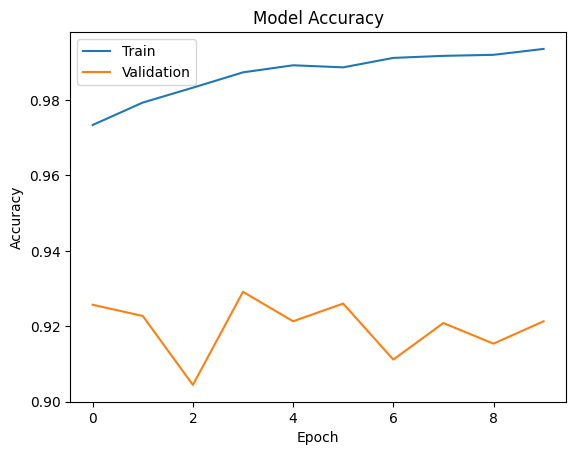

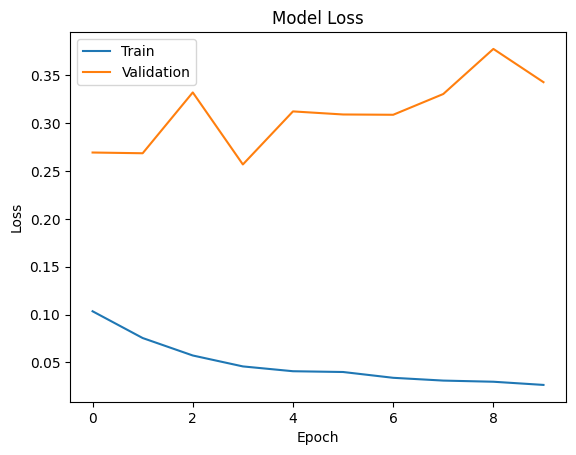

In [32]:
import matplotlib.pyplot as plt


plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(['Train', 'Validation'])
plt.show()

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Train', 'Validation'])
plt.show()

In [33]:
history = model.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=32,
    validation_data=(X_test, y_test),
    class_weight=class_weights
)

Epoch 1/10
799/799 ━━━━━━━━━━━━━━━━━━━━ 11s 14ms/step - Precision: 0.6946 - Recall: 0.9482 - accuracy: 0.9671 - loss: 0.1368 - val_Precision: 0.3527 - val_Recall: 0.5290 - val_accuracy: 0.8989 - val_loss: 0.3605
Epoch 2/10
799/799 ━━━━━━━━━━━━━━━━━━━━ 19s 12ms/step - Precision: 0.6117 - Recall: 0.9465 - accuracy: 0.9541 - loss: 0.1451 - val_Precision: 0.2853 - val_Recall: 0.6094 - val_accuracy: 0.8656 - val_loss: 0.4352
Epoch 3/10
799/799 ━━━━━━━━━━━━━━━━━━━━ 11s 13ms/step - Precision: 0.8037 - Recall: 0.9721 - accuracy: 0.9814 - loss: 0.0859 - val_Precision: 0.3576 - val_Recall: 0.5491 - val_accuracy: 0.8992 - val_loss: 0.3788
Epoch 4/10
799/799 ━━━━━━━━━━━━━━━━━━━━ 21s 15ms/step - Precision: 0.7937 - Recall: 0.9693 - accuracy: 0.9802 - loss: 0.0822 - val_Precision: 0.3432 - val_Recall: 0.5179 - val_accuracy: 0.8967 - val_loss: 0.3421
Epoch 5/10
799/799 ━━━━━━━━━━━━━━━━━━━━ 20s 14ms/step - Precision: 0.7686 - Recall: 0.9682 - accuracy: 0.9773 - loss: 0.0892 - val_Precision: 0.3080 - v

In [35]:
results = model.evaluate(X_test, y_test)

print(results)

200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - Precision: 0.3092 - Recall: 0.6205 - accuracy: 0.8763 - loss: 0.5000
[0.5000220537185669, 0.8762515783309937, 0.3092324733734131, 0.6205357313156128]


In [36]:
loss, accuracy, precision, recall = model.evaluate(X_test, y_test)

print("Loss:", loss)
print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)

200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - Precision: 0.3092 - Recall: 0.6205 - accuracy: 0.8763 - loss: 0.5000
Loss: 0.5000220537185669
Accuracy: 0.8762515783309937
Precision: 0.3092324733734131
Recall: 0.6205357313156128


In [37]:
results = model.evaluate(X_test, y_test)

for name, value in zip(model.metrics_names, results):
    print(name, ":", value)

200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - Precision: 0.3092 - Recall: 0.6205 - accuracy: 0.8763 - loss: 0.5000
loss : 0.5000220537185669
compile_metrics : 0.8762515783309937


In [39]:
y_pred_prob = model.predict(X_test)
y_pred = (y_pred_prob > 0.5).astype(int)

200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


In [40]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)

Confusion Matrix:
 [[5323  621]
 [ 170  278]]


In [41]:
from sklearn.metrics import classification_report, f1_score

print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))


Classification Report:
               precision    recall  f1-score   support

           0       0.97      0.90      0.93      5944
           1       0.31      0.62      0.41       448

    accuracy                           0.88      6392
   macro avg       0.64      0.76      0.67      6392
weighted avg       0.92      0.88      0.89      6392

F1 Score: 0.41276911655530807


In [42]:
y_pred = (y_pred_prob > 0.5)

In [43]:
y_pred = (y_pred_prob > 0.3).astype(int)

In [44]:
from tensorflow.keras.layers import LSTM
LSTM(64)

<LSTM name=lstm, built=False>

In [46]:
history = model.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=32,
    validation_data=(X_test, y_test),
    class_weight=class_weights
)

Epoch 1/10
799/799 ━━━━━━━━━━━━━━━━━━━━ 13s 16ms/step - Precision: 0.8162 - Recall: 0.9827 - accuracy: 0.9833 - loss: 0.0546 - val_Precision: 0.2708 - val_Recall: 0.6406 - val_accuracy: 0.8539 - val_loss: 0.5520
Epoch 2/10
799/799 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - Precision: 0.8413 - Recall: 0.9872 - accuracy: 0.9860 - loss: 0.0456 - val_Precision: 0.3722 - val_Recall: 0.5491 - val_accuracy: 0.9035 - val_loss: 0.4025
Epoch 3/10
799/799 ━━━━━━━━━━━━━━━━━━━━ 18s 21ms/step - Precision: 0.9196 - Recall: 0.9889 - accuracy: 0.9932 - loss: 0.0340 - val_Precision: 0.2523 - val_Recall: 0.6696 - val_accuracy: 0.8378 - val_loss: 0.7082
Epoch 4/10
799/799 ━━━━━━━━━━━━━━━━━━━━ 13s 16ms/step - Precision: 0.8389 - Recall: 0.9900 - accuracy: 0.9860 - loss: 0.0463 - val_Precision: 0.3735 - val_Recall: 0.5603 - val_accuracy: 0.9033 - val_loss: 0.4181
Epoch 5/10
799/799 ━━━━━━━━━━━━━━━━━━━━ 12s 14ms/step - Precision: 0.8073 - Recall: 0.9810 - accuracy: 0.9822 - loss: 0.0621 - val_Precision: 0.1883 - va

In [47]:
from tensorflow.keras.layers import Dropout

model = Sequential([
    Embedding(vocab_size, 64, input_length=max_len),
    LSTM(64),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [48]:
model.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy', 'Precision', 'Recall']
)

In [49]:
history = model.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=32,
    validation_data=(X_test, y_test),
    class_weight=class_weights
)

Epoch 1/10
799/799 ━━━━━━━━━━━━━━━━━━━━ 24s 27ms/step - Precision: 0.2242 - Recall: 0.7715 - accuracy: 0.7967 - loss: 0.4444 - val_Precision: 0.4977 - val_Recall: 0.7254 - val_accuracy: 0.9294 - val_loss: 0.2226
Epoch 2/10
799/799 ━━━━━━━━━━━━━━━━━━━━ 23s 28ms/step - Precision: 0.3947 - Recall: 0.9175 - accuracy: 0.8955 - loss: 0.2443 - val_Precision: 0.3932 - val_Recall: 0.8214 - val_accuracy: 0.8986 - val_loss: 0.2437
Epoch 3/10
799/799 ━━━━━━━━━━━━━━━━━━━━ 37s 23ms/step - Precision: 0.4762 - Recall: 0.9387 - accuracy: 0.9233 - loss: 0.1741 - val_Precision: 0.3470 - val_Recall: 0.8103 - val_accuracy: 0.8798 - val_loss: 0.2551
Epoch 4/10
799/799 ━━━━━━━━━━━━━━━━━━━━ 18s 22ms/step - Precision: 0.5622 - Recall: 0.9571 - accuracy: 0.9447 - loss: 0.1394 - val_Precision: 0.3894 - val_Recall: 0.7902 - val_accuracy: 0.8985 - val_loss: 0.2667
Epoch 5/10
799/799 ━━━━━━━━━━━━━━━━━━━━ 17s 21ms/step - Precision: 0.6063 - Recall: 0.9632 - accuracy: 0.9535 - loss: 0.1150 - val_Precision: 0.4814 - v

In [50]:
results = model.evaluate(X_test, y_test)

for name, value in zip(model.metrics_names, results):
    print(name, ":", value)

200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - Precision: 0.4176 - Recall: 0.7746 - accuracy: 0.9085 - loss: 0.3184
loss : 0.31835487484931946
compile_metrics : 0.9084793329238892


In [51]:
y_pred_prob = model.predict(X_test)
y_pred = (y_pred_prob > 0.5).astype(int)

200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step


In [52]:
from sklearn.metrics import classification_report, f1_score

print(classification_report(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.98      0.92      0.95      5944
           1       0.42      0.77      0.54       448

    accuracy                           0.91      6392
   macro avg       0.70      0.85      0.75      6392
weighted avg       0.94      0.91      0.92      6392

F1 Score: 0.5426114151681001
